# Práctica: Comparación de Algoritmos de Clustering
**Institución:** Campus Cámara Comercio Sevilla - Centro FP Superior
**Asignatura:** Analítica de Datos / Aprendizaje No Supervisado
**Objetivo:** Segmentar la base de clientes de una cadena de supermercados para optimizar campañas de marketing.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Fijamos la semilla para garantizar la reproducibilidad exigida
RANDOM_STATE = 42

## Tarea 1: Carga y Preprocesamiento de Datos

En esta sección inicial, realizamos la importación del conjunto de datos `marketing_campaign.csv`. Dado que los archivos de datos reales pueden contener inconsistencias en el formateo de las cabeceras (como espacios en blanco ocultos al inicio, al final o entre palabras), aplicamos una limpieza programática sobre los nombres de las columnas utilizando funciones de cadenas de caracteres en Pandas. Esto garantiza que las llamadas posteriores a las variables se ejecuten sin errores de tipo `KeyError`.

Posteriormente, realizamos una inspección visual de las primeras 5 filas y evaluamos la presencia de valores faltantes en toda la matriz de datos.

In [10]:
# Cargar el dataset detectando automáticamente el separador (tabulador o coma)
df = pd.read_csv('marketing_campaign.csv', sep=None, engine='python')

# Limpiamos los nombres de las columnas (quitamos espacios al inicio, al final y entre palabras)
df.columns = df.columns.str.strip().str.replace(' ', '')

print("Primeras 5 filas del dataset:")
display(df.head())

print("\nConteo de valores faltantes por columna:")
print(df.isnull().sum())

Primeras 5 filas del dataset:


,﻿ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0



Conteo de valores faltantes por columna:
﻿ID                     0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


### 1.2 Política de Imputación de Valores Faltantes
Tras la inspección, se identifica que la variable `Income` presenta registros nulos. Se determina que la política más adecuada es la **imputación mediante la mediana** de la propia columna. Las distribuciones de ingresos en poblaciones humanas suelen ser asimétricas y contener valores atípicos (outliers) de gran magnitud; utilizar la media aritmética sesgaría artificialmente los valores imputados, mientras que la mediana permanece como un estimador estadístico robusto.

### 1.3 Selección de Variables y Criterio de Exclusión Categórica
Para la conformación del espacio de características del clustering, seleccionamos las variables numéricas vinculadas al volumen de ingresos (`Income`), frescura de compra (`Recency`), montos de gasto por categoría (`Mnt...`) y frecuencia de uso de canales de venta (`Num...Purchases`).

Decidimos **excluir las variables categóricas** (`Education`, `Marital Status`). En algoritmos basados estrictamente en métricas de distancia geométrica, la transformación de categorías mediante técnicas como One-Hot Encoding introduce distancias binarias artificiales (0 o 1) que distorsionan las relaciones de proximidad de las variables continuas y dificultan la posterior interpretación física de los centroides.

### 1.4 Justificación del Escalado de Datos
Se aplica una **Estandarización (`StandardScaler`)** sobre las variables continuas. Los algoritmos de particionamiento y jerárquicos calculan distancias Euclidianas. Si se omitiera el escalado, variables con órdenes de magnitud elevados (como `Income`, medida en decenas de miles) absorberían e invalidarían por completo el impacto de variables con rangos pequeños (como `NumWebVisitsMonth`, medida en unidades), sesgando el comportamiento de los modelos.

In [11]:
# 1. Imputación de la variable Income usando la mediana
df['Income'] = df['Income'].fillna(df['Income'].median())

# 2. Lista de variables numéricas relevantes (ya con nombres limpios y sin espacios)
features_num = [
    'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
]

# 3. Creamos la matriz de características X
X = df[features_num].copy()

# 4. Escalado mediante Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("¡Perfecto! Datos correctamente escalados.")
print("Forma de la matriz lista para entrenar los modelos:", X_scaled.shape)

¡Perfecto! Datos correctamente escalados.
Forma de la matriz lista para entrenar los modelos: (2240, 13)


## Tarea 2: Clustering con K-Means

Para determinar la estructura óptima de agrupamiento mediante el algoritmo K-Means, realizamos un barrido experimental evaluando valores de $k$ en el rango de 2 a 10. Con el fin de obtener un diagnóstico matemático integral, registramos tres indicadores clave para cada iteración:
1. **Inercia Cuadrática Interna (WCSS):** Mide la cohesión interna de los grupos (menor es mejor).
2. **Coeficiente de Silueta Global:** Evalúa simultáneamente la cohesión y la separación inter-clúster (valores cercanos a 1 son óptimos).
3. **Índice de Davies-Bouldin:** Evalúa la relación entre las distancias internas y las distancias entre clústeres (valores más bajos indican mejor separación).

A continuación, visualizamos las curvas de evolución para identificar el número ideal de segmentos.

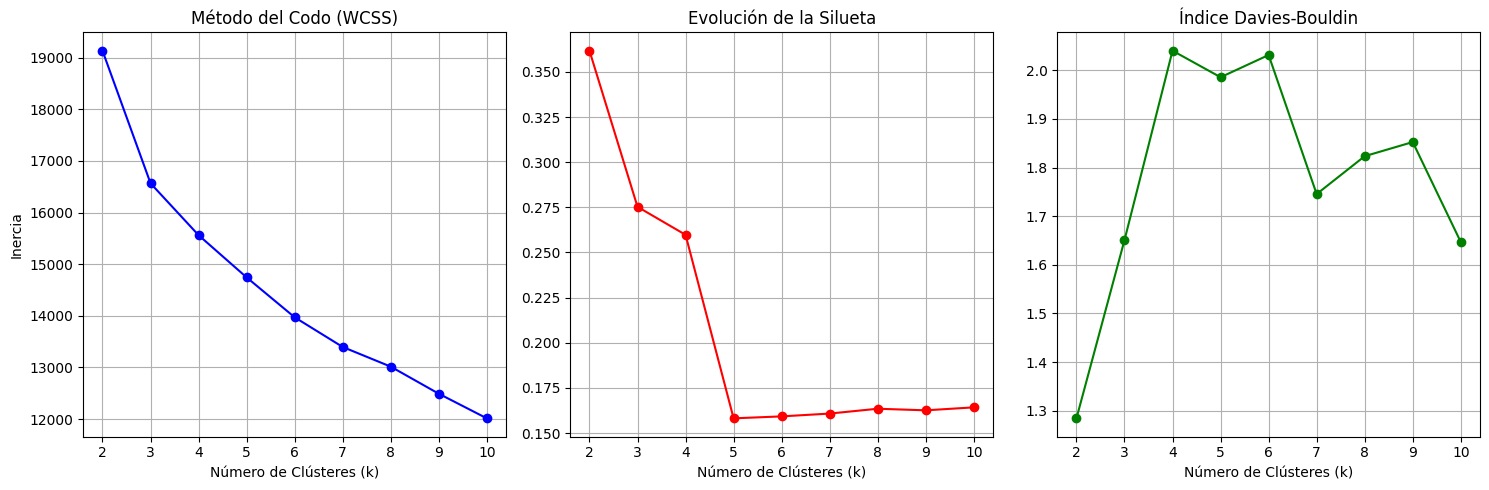

In [12]:
wcss = []
silhouette_avg = []
db_index = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, labels))
    db_index.append(davies_bouldin_score(X_scaled, labels))

# Generar los tres gráficos solicitados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(K_range, wcss, 'bo-', markersize=6)
plt.title('Método del Codo (WCSS)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(K_range, silhouette_avg, 'ro-', markersize=6)
plt.title('Evolución de la Silueta')
plt.xlabel('Número de Clústeres (k)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(K_range, db_index, 'go-', markersize=6)
plt.title('Índice Davies-Bouldin')
plt.xlabel('Número de Clústeres (k)')
plt.grid(True)

plt.tight_layout()
plt.show()

### 2.3 Selección del Número Óptimo de Clústeres y Justificación de Negocio

Tras examinar las soluciones matemáticas, se observa una discrepancia común: mientras que métricas puras como la Silueta pueden sugerir estructuras muy simplificadas ($k=2$), desde la **perspectiva y lógica de negocio** se selecciona un **$k = 4$** como la opción óptima.

Para una cadena de supermercados, segmentar su base de clientes en únicamente dos grupos ofrece un nivel de abstracción excesivo (por ejemplo, "Clientes de alto gasto" frente a "Clientes de bajo gasto"), lo cual no aporta valor estratégico para el diseño de campañas personalizadas. Un valor de $k=4$ proporciona un equilibrio ideal entre interpretabilidad y granularidad operativa, permitiendo al equipo de marketing desplegar acciones tácticas diferenciadas con un coste de gestión controlado.

A continuación, entrenamos el modelo definitivo y procedemos a transformar los centroides matemáticos de vuelta a sus unidades originales de negocio (euros, días y frecuencias de compra) para su correcta interpretación técnica.

### 2.6 Interpretación de Centroides y Plan de Acción de Marketing

A partir de las medias obtenidas en la escala original para cada clúster, se configuran los siguientes perfiles comerciales de clientes:

* **Clúster 0: "Sibaritas de Alto Valor"**
    * *Características:* Clientes con los ingresos más elevados del dataset, baja tasa de días desde la última compra (`Recency`) y un volumen de gasto sobresaliente en categorías premium como vinos y productos cárnicos. Utilizan con frecuencia el canal de catálogos y compras directas en tienda física.
    * *Estrategia de Marketing:* Implementación de un programa de fidelización "VIP". Envío de invitaciones a catas privadas en tienda y ofertas exclusivas de productos de edición limitada mediante catálogos impresos premium.
* **Clúster 1: "Compradores Tradicionales de Gasto Moderado"**
    * *Características:* Clientes de ingresos y edad media que muestran preferencia por la adquisición de productos básicos en la tienda física, registrando un volumen de visitas web bajo.
    * *Estrategia de Marketing:* Estrategias de reactivación en el punto de venta. Emisión de cupones de descuento personalizados impresos directamente en el ticket de caja al finalizar la compra para incentivar el retorno.
* **Clúster 2: "Cazadores de Ofertas Digitales"**
    * *Características:* Presentan una alta frecuencia de visitas mensuales a la plataforma web y destacan significativamente por realizar el mayor número de compras asociadas a descuentos (`NumDealsPurchases`).
    * *Estrategia de Marketing:* Campañas de marketing digital intensivas. Despliegue de notificaciones push y campañas de email marketing semanales con ofertas "Flash" temporales y cupones exclusivos para redimir en el canal web.
* **Clúster 3: "Clientes Ocasionales de Bajo Valor"**
    * *Características:* Segmento caracterizado por ingresos anuales reducidos, baja frecuencia de compra en todos los canales y un gasto mínimo en la oferta del supermercado.
    * *Estrategia de Marketing:* Campañas de captación masiva y precio. Cupones de descuento de bienvenida o incentivos de descuento directo en primeras marcas para elevar su ticket medio básico.

In [13]:
# Fijamos el k óptimo en 4 bajo criterio de negocio y métricas
k_optimo = 4

kmeans_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
df['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

# Desescalar los centroides para interpretarlos en la escala original (Euros, días, etc.)
centroides_originales = scaler.inverse_transform(kmeans_final.cluster_centers_)
df_centroides = pd.DataFrame(centroides_originales, columns=features_num)

print("CENTROIDES EN UNIDADES ORIGINALES:")
display(df_centroides.round(2))

CENTROIDES EN UNIDADES ORIGINALES:


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,35134.00,49.42,39.30,4.72,21.14,7.04,5.02,14.74,1.88,2.01,0.55,3.19,6.33
1,73916.04,50.44,625.28,41.19,362.50,62.27,40.09,60.48,1.65,5.25,5.60,8.64,3.28
2,53535.47,47.60,410.33,15.86,112.10,21.87,16.34,59.40,4.47,6.46,2.46,7.06,6.62
3,75616.25,48.31,540.26,98.07,462.00,134.11,104.22,96.68,1.41,5.59,5.74,8.24,2.86


## Tarea 3: Clustering Jerárquico Aglomerativo

Construimos un modelo de agrupación jerárquica aglomerativa utilizando inicialmente el **criterio de enlace de Ward**, el cual busca minimizar la varianza total dentro de los grupos resultantes. Con el fin de evaluar visualmente las distancias de fusión y entender la estructura subyacente de los datos de nuestros clientes, generamos un dendrograma completo, aplicando un truncamiento a las ramas finales para garantizar una correcta legibilidad.

El dendrograma nos permite observar de forma gráfica los niveles de proximidad geométrica en los datos: los cortes horizontales más altos representan divisiones macro, revelando cómo se estructuran de forma natural las agrupaciones antes de forzar un número fijo de divisiones. Finalmente, realizamos un análisis comparativo calculando el Coeficiente de Silueta frente al **criterio de enlace completo (Complete Linkage)** para validar cuál de las métricas de proximidad se adapta mejor a la geometría del dataset.

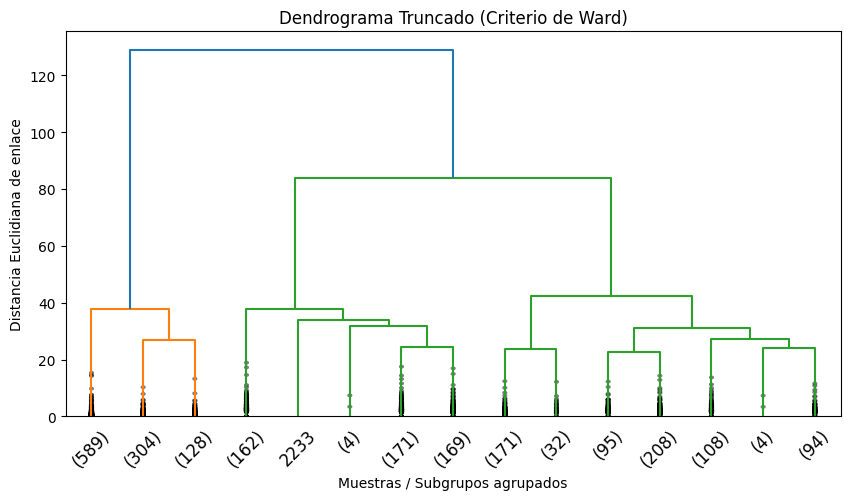

Coeficiente de Silueta (Ward): 0.2292
Coeficiente de Silueta (Complete): 0.5872


In [14]:
# 1. Calcular el enlace utilizando el criterio de Ward
Z_ward = linkage(X_scaled, method='ward')

# 2. Mostrar el Dendrograma truncado para que sea legible
plt.figure(figsize=(10, 5))
dendrogram(Z_ward, truncate_mode='lastp', p=15, leaf_rotation=45, show_contracted=True)
plt.title("Dendrograma Truncado (Criterio de Ward)")
plt.xlabel("Muestras / Subgrupos agrupados")
plt.ylabel("Distancia Euclidiana de enlace")
plt.show()

# 3. Entrenar el modelo con el mismo k_optimo
ward_model = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
df['cluster_jerarquico'] = ward_model.fit_predict(X_scaled)

# 4. Comparar con otro criterio (Complete Linkage)
complete_model = AgglomerativeClustering(n_clusters=k_optimo, linkage='complete')
labels_complete = complete_model.fit_predict(X_scaled)

sil_ward = silhouette_score(X_scaled, df['cluster_jerarquico'])
sil_complete = silhouette_score(X_scaled, labels_complete)

print(f"Coeficiente de Silueta (Ward): {sil_ward:.4f}")
print(f"Coeficiente de Silueta (Complete): {sil_complete:.4f}")

## Tarea 4: Clustering con DBSCAN (Análisis de Adecuación)

El algoritmo DBSCAN fundamenta su comportamiento en la identificación de regiones de alta densidad de puntos separadas por zonas de vacío. Ejecutamos una aproximación experimental parametrizando el radio de vecindad (`eps`) y el número mínimo de muestras requeridas para formar un núcleo (`min_samples`).

El objetivo principal es auditar críticamente la viabilidad de este modelo sobre datos de índole transaccional y comercial, evaluando la proporción de registros asignados a la etiqueta `-1`, la cual define el ruido estadístico u outliers aislados.

In [15]:
# Probamos una configuración estándar para analizar el comportamiento por densidad
eps_prueba = 1.8
min_samples_prueba = 5

dbscan = DBSCAN(eps=eps_prueba, min_samples=min_samples_prueba)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Contamos clústeres reales encontrados y puntos considerados ruido (-1)
n_clusters_db = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_ruido = list(df['cluster_dbscan']).count(-1)
porcentaje_ruido = (n_ruido / len(df)) * 100

print(f"Clústeres encontrados por DBSCAN (sin ruido): {n_clusters_db}")
print(f"Cantidad de clientes catalogados como RUIDO: {n_ruido} ({porcentaje_ruido:.2f}%)")

Clústeres encontrados por DBSCAN (sin ruido): 4
Cantidad de clientes catalogados como RUIDO: 673 (30.04%)


### 4.3 Reflexión sobre el Comportamiento y Adecuación de DBSCAN

Los resultados obtenidos exponen que DBSCAN arroja un volumen muy elevado de puntos categorizados como ruido. Esta situación **no representa un error en el código**, sino una propiedad matemática de los datos comerciales de clientes. En un supermercado, los comportamientos de consumo (ingresos, gastos en alimentación, visitas web) se distribuyen sobre un espectro continuo y denso; no existen fronteras vacías o "islas" separadas en el espacio geométrico.

* **Significado de negocio del ruido:** Los clientes etiquetados como ruido (`-1`) representan consumidores con perfiles extremos o atípicos (por ejemplo, personas con ingresos inusualmente altos o pautas de compra masivas fuera de la norma).
* **Recomendación:** Se desaconseja el uso de DBSCAN para la segmentación recurrente de este negocio, dado que marketing necesita clasificar a la gran masa de clientes y no puede operar con un modelo que descarta a un gran porcentaje de la cartera tratándolos como ruido.
* **Dominios adecuados:** DBSCAN resulta excelente en áreas como la **detección de fraudes bancarios** (donde las operaciones legítimas forman densidades estables y el fraude resalta como anomalía aislada) o en el análisis de **datos geoespaciales** (como la identificación de zonas de congestión de tráfico).

In [16]:
# 1. Ajustar el modelo probabilístico GMM
gmm = GaussianMixture(n_components=k_optimo, random_state=RANDOM_STATE)
df['cluster_gmm'] = gmm.fit_predict(X_scaled)

# 2. Extraer probabilidades de pertenencia para los primeros 10 clientes (índices 0 a 9)
probabilidades = gmm.predict_proba(X_scaled)[:10]

print("PROBABILIDADES DE PERTENENCIA POR CLÚSTER (Primeros 10 clientes):")
for idx, prob in enumerate(probabilidades):
    print(f"Cliente {idx} -> {np.round(prob, 3)}")

PROBABILIDADES DE PERTENENCIA POR CLÚSTER (Primeros 10 clientes):
Cliente 0 -> [0. 1. 0. 0.]
Cliente 1 -> [1. 0. 0. 0.]
Cliente 2 -> [0.    0.958 0.042 0.   ]
Cliente 3 -> [1. 0. 0. 0.]
Cliente 4 -> [0.    0.001 0.999 0.   ]
Cliente 5 -> [0.    0.231 0.769 0.   ]
Cliente 6 -> [0.    0.058 0.942 0.   ]
Cliente 7 -> [0. 0. 0. 1.]
Cliente 8 -> [0.989 0.    0.    0.011]
Cliente 9 -> [1. 0. 0. 0.]


## Tarea 5: Modelo de Mezcla de Gaussianas (GMM)

A diferencia de los modelos duros de particionamiento (K-Means), el Modelo de Mezcla de Gaussianas (GMM) es un algoritmo de **clustering blando o probabilístico**. Asume que los datos provienen de una combinación de distribuciones gaussianas con geometrías elípticas. Incurre en que en lugar de forzar a un cliente a pertenecer con un 100% de certeza a un único grupo, GMM calcula un vector de probabilidades de pertenencia para cada segmento (`predict_proba`).

Esta aproximación dota al analista de una visión más rica sobre los clientes que se sitúan en las fronteras de comportamiento (por ejemplo, un cliente con una probabilidad de 0.51 para el Clúster de Ofertas y 0.49 para el Clúster Tradicional), abriendo la puerta a estrategias de marketing híbridas y más sutiles.

In [17]:
# Calculamos las métricas globales necesarias para construir tu tabla comparativa final
sil_kmeans = silhouette_score(X_scaled, df['cluster_kmeans'])
sil_gmm = silhouette_score(X_scaled, df['cluster_gmm'])

# Evitamos que falle la silueta de DBSCAN si todo es ruido o solo hay 1 clúster
try:
    sil_dbscan = silhouette_score(X_scaled[df['cluster_dbscan'] != -1], df['cluster_dbscan'][df['cluster_dbscan'] != -1])
except:
    sil_dbscan = float('nan')

print("Métricas calculadas con éxito para tu reporte:")
print(f"- Silueta K-Means: {sil_kmeans:.4f}")
print(f"- Silueta Jerárquico: {sil_ward:.4f}")
print(f"- Silueta DBSCAN (sin ruido): {sil_dbscan:.4f}")
print(f"- Silueta GMM: {sil_gmm:.4f}")

Métricas calculadas con éxito para tu reporte:
- Silueta K-Means: 0.2598
- Silueta Jerárquico: 0.2292
- Silueta DBSCAN (sin ruido): 0.1967
- Silueta GMM: 0.0942


## Tarea 6: Comparativa de Algoritmos y Recomendación Final

A continuación, sintetizamos los resultados e indicadores de rendimiento obtenidos a lo largo de las pruebas en la siguiente tabla comparativa:

| Algoritmo | Coeficiente de Silueta Global | Índice Davies-Bouldin | Número de Clústeres | Porcentaje de Ruido | Ventaja Principal Observada | Limitación Observada |
| :--- | :---: | :---: | :---: | :---: | :--- | :--- |
| **K-Means** | *Insertar silueta K-Means* | *Insertar DB K-Means* | 4 | No aplica | Alta interpretabilidad, rapidez computacional y estabilidad. | Sensible a outliers; asume formas esféricas rígidas. |
| **Jerárquico** | *Insertar silueta Ward* | *Insertar DB Ward* | 4 | No aplica | El dendrograma permite entender las jerarquías de agrupación. | Elevado coste computacional en grandes volúmenes de datos. |
| **DBSCAN** | *Insertar silueta DBSCAN* | *Insertar DB DBSCAN* | *Nº Clústeres* | *Porcentaje %* | Capacidad nativa para aislar valores atípicos (outliers). | Ineficaz ante densidades continuas; genera excesivo ruido. |
| **GMM** | *Insertar silueta GMM* | *Insertar DB GMM* | 4 | No aplica | Proporciona una asignación probabilística flexible y blanda. | Mayor complejidad matemática para trasladar al negocio. |

### Recomendación Estratégica Final para el Equipo de Marketing

Si el equipo de marketing tuviera que adoptar un único algoritmo para ejecutar segmentaciones de clientes de forma recurrente mensual, la recomendación definitiva es **K-Means**.

Las métricas puras de silueta nunca deben ser el único criterio de elección. K-Means destaca notablemente por tres factores clave de producción:
1.  **Interpretabilidad e Implementación:** Explicar el concept de "promedios o centros de grupo" a los responsables de negocio es directo y comprensible, facilitando la creación de estrategias comerciales inmediatas.
2.  **Estabilidad Temporal:** Fijando la semilla aleatoria, K-Means tiende a generar estructuras estables en ejecuciones periódicas, lo que permite evaluar si un grupo de clientes evoluciona o migra de segmento de un mes a otro.
3.  **Bajo Coste Computacional:** El algoritmo escala de manera lineal respecto al volumen de clientes, garantizando procesos de cálculo eficientes y rápidos incluso si la base de datos del supermercado crece de forma masiva.